In [ ]:
import torch
import torch.nn as nn
import snntorch as snn
from snntorch import surrogate
import numpy as np
from pathlib import Path
import zipfile
import json
import wfdb
from scipy import signal
from math import gcd
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [ ]:
application = 'emg'
OUTPUT_DIR = Path(application)
OUTPUT_DIR.mkdir(exist_ok=True)

In [ ]:
class ConvSNN_TC9(nn.Module):
    """
    TC9:
    Conv3x3 valid -> LIF          (16 -> 14)
    Conv3x3 same  -> LIF          (14 -> 14)
    MaxPool2x2 s=2                (14 -> 7)
    Conv3x3 valid -> LIF          (7 -> 5)
    Flatten (16*5*5 = 400)
    Dense 400->5 -> integratore
    Dimensioni: 16 -> 14 -> 14 -> 7 -> 5
    """
    def __init__(
        self,
        in_channels=2,
        beta_val=0.9,
        threshold_hidden=0.3,
        threshold_out=1e9,
        ch1=16,
        ch2=8,
        ch3=16,
        out_dim=5,
        input_h=16,
        input_w=16,
    ):
        super().__init__()

        self.in_channels = in_channels
        self.input_h = input_h
        self.input_w = input_w

        spike_grad = surrogate.fast_sigmoid()

        # L1: 16 -> 14
        self.conv1 = nn.Conv2d(in_channels, ch1,
                               kernel_size=3, stride=1, padding=0, bias=False)
        self.H1 = input_h      # 14
        self.W1 = input_w      # 14
        self.lif1 = snn.Leaky(
            beta=beta_val, threshold=threshold_hidden,
            learn_beta=True, learn_threshold=False,
            spike_grad=spike_grad, reset_mechanism="subtract"
        )

        # L2: 14 -> 14 (same: padding=1, stride=1)
        self.conv2 = nn.Conv2d(ch1, ch2,
                               kernel_size=3, stride=1, padding=1, bias=False)
        self.H2 = self.H1 - 2          # 14
        self.W2 = self.W1 - 2          # 14
        self.lif2 = snn.Leaky(
            beta=beta_val, threshold=threshold_hidden,
            learn_beta=True, learn_threshold=False,
            spike_grad=spike_grad, reset_mechanism="subtract"
        )

        # MaxPool: 14 -> 7 (kernel=2, stride=2)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.H2p = self.H2 // 2    # 7
        self.W2p = self.W2 // 2    # 7

        # L3: 7 -> 5
        self.conv3 = nn.Conv2d(ch2, ch3,
                               kernel_size=3, stride=1, padding=0, bias=False)
        self.H3 = self.H2p - 2     # 5
        self.W3 = self.W2p - 2     # 5
        self.lif3 = snn.Leaky(
            beta=beta_val, threshold=threshold_hidden,
            learn_beta=True, learn_threshold=False,
            spike_grad=spike_grad, reset_mechanism="subtract"
        )

        flat_dim = ch3 * self.H3 * self.W3  # 16*5*5 = 400

        # Dense OUT diretto: 400 -> 5
        self.fc_out = nn.Linear(flat_dim, out_dim, bias=False)
        beta_out = torch.ones(out_dim) * 0.99
        self.li_out = snn.Leaky(
            beta=beta_out, threshold=threshold_out,
            learn_beta=True, learn_threshold=False,
            spike_grad=spike_grad, reset_mechanism="none"
        )

    def forward(self, x, mem_init=None):
        B, T, C, H, W = x.shape
        x = x.to(next(self.parameters()).device)

        if mem_init is not None:
            mem1    = mem_init["mem1"].to(x.device).clone()
            mem2    = mem_init["mem2"].to(x.device).clone()
            mem3    = mem_init["mem3"].to(x.device).clone()
            mem_out = mem_init["mem_out"].to(x.device).clone()
        else:
            mem1    = torch.zeros((B, self.conv1.out_channels, self.H1, self.W1), device=x.device)
            mem2    = torch.zeros((B, self.conv2.out_channels, self.H2, self.W2), device=x.device)
            mem3    = torch.zeros((B, self.conv3.out_channels, self.H3, self.W3), device=x.device)
            mem_out = torch.zeros((B, self.fc_out.out_features), device=x.device)

        mem_rec = []
        for step in range(T):
            x_t = x[:, step]
            cur1 = self.conv1(x_t)
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.conv2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2p = self.pool2(spk2)
            cur3 = self.conv3(spk2p)
            spk3, mem3 = self.lif3(cur3, mem3)
            feat = spk3.view(B, -1)
            cur_out = self.fc_out(feat)
            _, mem_out = self.li_out(cur_out, mem_out)
            mem_rec.append(mem_out)

        # restituisce anche gli stati finali per il carry
        mem_final = {
            "mem1":    mem1.detach().clone(),
            "mem2":    mem2.detach().clone(),
            "mem3":    mem3.detach().clone(),
            "mem_out": mem_out.detach().clone(),
        }

        return torch.stack(mem_rec, dim=0), mem_final

In [ ]:
CKPT_PATH = r"TC9_2_3_sr_1_20.pt"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = ConvSNN_TC9(in_channels=2).to(device)
ckpt  = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt['model_state'] if 'model_state' in ckpt else ckpt)
model.eval()
print("Checkpoint caricato")
print(model)

Checkpoint caricato
ConvSNN_TC8(
  (conv1): Conv2d(2, 16, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (lif1): Leaky()
  (conv2): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (lif2): Leaky()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (lif3): Leaky()
  (fc_out): Linear(in_features=400, out_features=5, bias=False)
  (li_out): Leaky()
)


In [ ]:
def hex_conv(num, bits):
    if num < 0:
        sign_extension = (1 << bits) - 1
        num = num & sign_extension
        hex_num = hex(num)[2:]
    else:
        binary = bin(num)[2:]
        if len(binary) < bits:
            zero_extension = "0" * int((bits - len(binary))//4)
            hex_num = zero_extension + hex(num)[2:]
        else:
            hex_num = hex(num)[2:]
    return hex_num

def to_int8_hex(x: int) -> str:
    x = int(x)
    if x > 127:  x = 127
    if x < -128: x = -128
    return hex_conv(x, 8)

def conv2d_int8(input_spike, weight, stride=1, padding=0):
    H, W = input_spike.shape
    kH, kW = weight.shape

    padded = np.pad(input_spike, pad_width=padding, mode="constant", constant_values=0)
    out_h = (H + 2*padding - kH) // stride + 1
    out_w = (W + 2*padding - kW) // stride + 1

    output = np.zeros((out_h, out_w), dtype=np.int32)
    for i in range(out_h):
        for j in range(out_w):
            region = padded[i*stride:i*stride+kH, j*stride:j*stride+kW]
            output[i, j] = np.sum(region.astype(np.int32) * weight.astype(np.int32))
    return output

In [ ]:
# ══════════════════════════════════════════════════════════════
# STEP 1 — QUANTIZZAZIONE PESI: int8 per-layer (simmetrica)
# ══════════════════════════════════════════════════════════════
def quantize_weights_int8(tensor):
    w = tensor.detach().cpu().float().numpy()
    scale = np.abs(w).max() / 127.0
    if scale == 0:
        return np.zeros_like(w, dtype=np.int8), 1.0
    w_q = np.clip(np.round(w / scale), -128, 127).astype(np.int8)
    return w_q, scale

def stats(name, w_float, w_int8, scale):
    w_f  = w_float.detach().cpu().float().numpy()
    w_dq = w_int8.astype(np.float32) * scale
    mae    = np.abs(w_f - w_dq).mean()
    maxae  = np.abs(w_f - w_dq).max()
    snr_db = 10 * np.log10(np.var(w_f) / (np.var(w_f - w_dq) + 1e-12) + 1e-12)
    clip_ratio = np.mean((w_int8 == -128) | (w_int8 == 127)) * 100
    print(f"  {name:10s}  scale={scale:.5f}  "
          f"min={w_int8.min():4d}  max={w_int8.max():4d}  "
          f"MAE={mae:.5f}  MaxAE={maxae:.5f}  "
          f"SNR={snr_db:6.2f}dB  clip={clip_ratio:.2f}%")

print("═══════════════════════════════════════════════════════")
print("  QUANTIZZAZIONE PESI  →  INT8  (simmetrica per-layer)")
print("═══════════════════════════════════════════════════════")

layers_w = {
    "conv1":  model.conv1.weight,
    "conv2":  model.conv2.weight,
    "conv3":  model.conv3.weight,
    "fc_out": model.fc_out.weight,   # ← corretto
}

quant = {}
for name, param in layers_w.items():
    w_int8, scale = quantize_weights_int8(param)
    quant[name] = {"int8": w_int8, "scale": scale}
    stats(name, param, w_int8, scale)

conv1_kernels = np.squeeze(quant["conv1"]["int8"])   # (16,  2, 3, 3)
conv2_kernels = np.squeeze(quant["conv2"]["int8"])   # ( 8, 16, 3, 3)
conv3_kernels = np.squeeze(quant["conv3"]["int8"])   # (16,  8, 3, 3)
fc_weights    = np.squeeze(quant["fc_out"]["int8"])  # (  5, 400)
print(f"  conv1  shape = {conv1_kernels.shape}")
print(f"  conv2  shape = {conv2_kernels.shape}")
print(f"  conv3  shape = {conv3_kernels.shape}")
print(f"  fc_out shape = {fc_weights.shape}")


# ══════════════════════════════════════════════════════════════
# STEP 2 — QUANTIZZAZIONE DECAY: Q12
# ══════════════════════════════════════════════════════════════
print("\n═══════════════════════════════════════════════════════")
print("  QUANTIZZAZIONE DECAY  →  Q12  (12 bit frazionari)")
print("═══════════════════════════════════════════════════════")

def quantize_decay_q12(lif_module, name):
    beta_float = float(lif_module.beta.detach().cpu().mean())
    decay_int  = round(beta_float * 4096)
    DECAY_HW   = 4096 - decay_int
    err        = abs(beta_float - decay_int / 4096.0)
    print(f"  {name:12s}  beta={beta_float:.6f}  "
          f"decay_int={decay_int:4d}  DECAY_HW={DECAY_HW:4d}  err={err:.2e}")
    return DECAY_HW, decay_int

DECAY_C1,  DI_C1  = quantize_decay_q12(model.lif1,   "lif1  (C1)")
DECAY_C2,  DI_C2  = quantize_decay_q12(model.lif2,   "lif2  (C2)")
DECAY_C3,  DI_C3  = quantize_decay_q12(model.lif3,   "lif3  (C3)")
DECAY_OUT, DI_OUT = quantize_decay_q12(model.li_out, "li_out (OUT)")  # ← corretto


# ══════════════════════════════════════════════════════════════
# STEP 3 — QUANTIZZAZIONE THRESHOLD: 16 bit
# ══════════════════════════════════════════════════════════════
print("\n═══════════════════════════════════════════════════════")
print("  QUANTIZZAZIONE THRESHOLD  →  16 bit")
print("═══════════════════════════════════════════════════════")

def quantize_threshold_correct(lif_module, scale_weights):
    thr   = float(lif_module.threshold)
    # Vc in unità int8: soglia = thr / scale_weights
    return max(0, int(round(thr / scale_weights)))

THRESH_C1 = quantize_threshold_correct(model.lif1, quant["conv1"]["scale"])
THRESH_C2 = quantize_threshold_correct(model.lif2, quant["conv2"]["scale"])
THRESH_C3 = quantize_threshold_correct(model.lif3, quant["conv3"]["scale"])
THRESH_OUT = quantize_threshold_correct(model.li_out, quant["fc_out"]["scale"])

# ══════════════════════════════════════════════════════════════
# RIEPILOGO FINALE
# ══════════════════════════════════════════════════════════════
print("\n═══════════════════════════════════════════════════════")
print("  RIEPILOGO QUANTIZZAZIONE")
print("═══════════════════════════════════════════════════════")
print(f"  Decay  Q12  : C1={DECAY_C1}  C2={DECAY_C2}  C3={DECAY_C3}  OUT={DECAY_OUT}")
print(f"  Thresh 16bit: C1={THRESH_C1}  C2={THRESH_C2}  C3={THRESH_C3}  OUT={THRESH_OUT}")


═══════════════════════════════════════════════════════
  QUANTIZZAZIONE PESI  →  INT8  (simmetrica per-layer)
═══════════════════════════════════════════════════════
  conv1       scale=0.00324  min= -93  max= 127  MAE=0.00080  MaxAE=0.00162  SNR= 44.72dB  clip=0.35%
  conv2       scale=0.00359  min=-122  max= 127  MAE=0.00089  MaxAE=0.00178  SNR= 40.13dB  clip=0.09%
  conv3       scale=0.00517  min=-127  max=  35  MAE=0.00128  MaxAE=0.00258  SNR= 36.85dB  clip=0.00%
  fc_out      scale=0.00239  min=-127  max=  77  MAE=0.00058  MaxAE=0.00119  SNR= 34.23dB  clip=0.00%

  conv1  shape = (16, 2, 3, 3)
  conv2  shape = (8, 16, 3, 3)
  conv3  shape = (16, 8, 3, 3)
  fc_out shape = (5, 400)

═══════════════════════════════════════════════════════
  QUANTIZZAZIONE DECAY  →  Q12  (12 bit frazionari)
═══════════════════════════════════════════════════════
  lif1  (C1)    beta=0.908080  decay_int=3719  DECAY_HW= 377  err=1.21e-04
  lif2  (C2)    beta=0.973226  decay_int=3986  DECAY_HW= 110  err

### ENCODING -- DELTA FLOATING POINT NON CLIPPATO/CASTATO A INT8

In [ ]:
# ── CONFIG ────────────────────────────────────────────────────
basedir          = Path(r"C:/Users/murfe/Desktop/PAPER/hyser_partial/1dof_dataset")
spike_maps_root  = Path(r"C:/Users/murfe/Desktop/PAPER/hyser_partial/spike_maps_updated_2")
mapped_root      = Path(r"C:/Users/murfe/Desktop/PAPER/hyser_partial/preprocessed_mapped")
delta_json_path  = Path(r"best_deltas_per_subject_session_finger_AGGmedian.json")

SUBJECT  = "subject01"
SESSION  = "session2"
FINGER   = "finger1"
SAMPLE   = "sample1"   # test set
fs       = 1000
DUR_S    = 25
T_TOTAL  = DUR_S * fs  # 25000

subj_session = f"{SUBJECT}_{SESSION}"

def resample_to_target(x, fs_in, fs_target, axis=0):
    fs_in, fs_target = int(fs_in), int(fs_target)
    g = gcd(fs_in, fs_target)
    return signal.resample_poly(x, fs_target // g, fs_in // g, axis=axis)

# STEP 1 — Carica EMG e quantizza in int8
folder   = basedir / subj_session
emg_name = f"1dof_raw_{FINGER}_{SAMPLE}"
emg_rec  = wfdb.rdrecord(str(folder / emg_name))
emg_raw  = resample_to_target(emg_rec.p_signal, float(emg_rec.fs), fs, axis=0)
emg_raw  = emg_raw[:T_TOTAL]

scale_emg   = np.percentile(np.abs(emg_raw), 99.5) / 127.0
emg_q       = np.clip(np.round(emg_raw / scale_emg), -128, 127).astype(np.int8)
print(f"[EMG]   shape={emg_q.shape}  scale={scale_emg:.6f}  "
      f"range=[{emg_q.min()},{emg_q.max()}]")

# STEP 2 — Carica delta e converti in dominio int8
with open(delta_json_path, "r") as f:
    data_agg = json.load(f)

deltas_float = np.array(
    data_agg["deltas"][subj_session][FINGER], dtype=np.float32
)
deltas_q = (deltas_float / scale_emg).astype(np.float32)

print(f"[DELTA] range float=[{deltas_float.min():.4f},{deltas_float.max():.4f}]  "
      f"range int8=[{deltas_q.min():.2f},{deltas_q.max():.2f}]")

# STEP 3 — Delta modulation → spike
def delta_modulate_1d(x, delta):
    x = np.asarray(x, dtype=np.float32)
    N = len(x)
    pos = np.zeros(N, dtype=np.uint8)
    neg = np.zeros(N, dtype=np.uint8)
    ref = x[0]
    for t in range(1, N):
        s = x[t]
        if s >= ref + delta:
            pos[t] = 1
            ref = s
        elif s <= ref - delta:
            neg[t] = 1
            ref = s
    return pos, neg

C   = 256
T   = emg_q.shape[0]
pos_all = np.zeros((T, C), dtype=np.uint8)
neg_all = np.zeros((T, C), dtype=np.uint8)

for ch in range(C):
    pos_all[:, ch], neg_all[:, ch] = delta_modulate_1d(
        emg_q[:, ch].astype(np.float32), deltas_q[ch]
    )

print(f"[SPIKES] POS={pos_all.mean()*100:.2f}%  NEG={neg_all.mean()*100:.2f}%")

# STEP 4 — Mappa in (T, 2, 16, 16) — STESSO layout del training
def spikes_to_2x16x16(pos, neg):
    """
    Layout fisico [B1|B3 / B2|B4] — identico a to_mapped_npz-2.py
    pos, neg: (T, 256) ordine naturale → (T, 2, 16, 16)
    """
    T = pos.shape[0]
    pos4 = pos.reshape(T, 4, 8, 8)
    neg4 = neg.reshape(T, 4, 8, 8)

    out_pos = np.zeros((T, 16, 16), dtype=np.float32)
    out_neg = np.zeros((T, 16, 16), dtype=np.float32)

    out_pos[:, 0:8,  0:8 ] = pos4[:, 0]   # B1 → top-left
    out_pos[:, 0:8,  8:16] = pos4[:, 2]   # B3 → top-right
    out_pos[:, 8:16, 0:8 ] = pos4[:, 1]   # B2 → bottom-left
    out_pos[:, 8:16, 8:16] = pos4[:, 3]   # B4 → bottom-right

    out_neg[:, 0:8,  0:8 ] = neg4[:, 0]
    out_neg[:, 0:8,  8:16] = neg4[:, 2]
    out_neg[:, 8:16, 0:8 ] = neg4[:, 1]
    out_neg[:, 8:16, 8:16] = neg4[:, 3]

    return np.stack([out_pos, out_neg], axis=1)   # (T, 2, 16, 16)

X_hw = spikes_to_2x16x16(pos_all, neg_all).astype(np.float32)
print(f"[X_hw]  shape={X_hw.shape}  dtype={X_hw.dtype}")

# STEP 5 — Verifica vs file NPZ del training
mapped_path = mapped_root / f"mapped_{subj_session}_{FINGER}_{SAMPLE}.npz"
X_npz = np.load(mapped_path)["spikes"]   # (T, 2, 16, 16)
FORCE_GAIN = float(np.load(mapped_path)["FORCE_GAIN"])

min_T = min(X_hw.shape[0], X_npz.shape[0])
diff  = np.abs(X_npz[:min_T].astype(float) - X_hw[:min_T].astype(float))

print(f"\n{'='*50}")
print(f"  VERIFICA vs NPZ training")
print(f"  diff.mean() = {diff.mean():.8f}  (atteso 0.0)")

[EMG]   shape=(25000, 256)  scale=0.001116  range=[-128,127]
[DELTA] range float=[0.0105,0.1043]  range int8=[9.45,93.46]
[SPIKES] POS=6.70%  NEG=7.28%
[X_hw]  shape=(25000, 2, 16, 16)  dtype=float32

  VERIFICA vs NPZ training
  diff.mean() = 0.00726656  (atteso 0.0)


In [ ]:
def x_hw_to_fpga_row(frame):
    """
    frame: (2, 16, 16)
    Mirror orizzontale: inverte le colonne, righe invariate.
    """
    return frame[:, :, ::-1].flatten().astype(int)   # (512,)

def to_hex8(val):
    """int8 → stringa HEX 2 char (es. -1 → 'FF', 127 → '7F')."""
    return f"{int(val) & 0xFF:02X}"

# ── spike_vec.txt ─────────────────────────────────────────────
SPIKE_FILE = OUTPUT_DIR / "spike_vec.txt"
with open(SPIKE_FILE, "w") as f:
    for t in range(T_TOTAL):
        row = x_hw_to_fpga_row(X_hw[t])
        f.write(" ".join(str(v) for v in row) + "\n")
print(f"✅ spike_vec.txt  — {T_TOTAL} righe × 512 (colonne invertite)")

# ── input_vec.txt — EMG: reshape 16×16, inverti colonne ──────
INPUT_FILE = OUTPUT_DIR / "input_vec.txt"
with open(INPUT_FILE, "w") as f:
    for t in range(T_TOTAL):
        row = emg_q[t].reshape(16, 16)[:, ::-1].flatten()
        f.write(" ".join(to_hex8(v) for v in row) + "\n")
print(f"✅ input_vec.txt  — {T_TOTAL} righe × 256 HEX (colonne invertite)")


# ── delta.hex — reshape 16×16, inverti colonne ───────────────
deltas_int8 = np.clip(np.round(deltas_float / scale_emg), -128, 127).astype(np.int8)
DELTA_FILE  = OUTPUT_DIR / "delta.hex"
with open(DELTA_FILE, "w") as f:
    for v in deltas_int8.reshape(16, 16)[:, ::-1].flatten():
        f.write(to_hex8(v) + "\n")
print(f"✅ delta.hex      — 256 valori HEX (colonne invertite)")

✅ spike_vec.txt  — 25000 righe × 512 (colonne invertite)
✅ input_vec.txt  — 25000 righe × 256 HEX (colonne invertite)
✅ delta.hex      — 256 valori HEX (colonne invertite)


In [ ]:
# ── estrai topologia automaticamente dal modello ──────────────
def get_hw_shapes(model, input_h=16, input_w=16):
    p1 = model.conv1.padding[0] if isinstance(model.conv1.padding, tuple) else model.conv1.padding
    k1 = model.conv1.kernel_size[0] if isinstance(model.conv1.kernel_size, tuple) else model.conv1.kernel_size
    H1 = (input_h + 2*p1 - k1) + 1
    W1 = (input_w + 2*p1 - k1) + 1

    p2 = model.conv2.padding[0] if isinstance(model.conv2.padding, tuple) else model.conv2.padding
    k2 = model.conv2.kernel_size[0] if isinstance(model.conv2.kernel_size, tuple) else model.conv2.kernel_size
    H2 = (H1 + 2*p2 - k2) + 1
    W2 = (W1 + 2*p2 - k2) + 1

    H2p = H2 // 2   # MaxPool 2x2
    W2p = W2 // 2

    p3 = model.conv3.padding[0] if isinstance(model.conv3.padding, tuple) else model.conv3.padding
    k3 = model.conv3.kernel_size[0] if isinstance(model.conv3.kernel_size, tuple) else model.conv3.kernel_size
    H3 = (H2p + 2*p3 - k3) + 1
    W3 = (W2p + 2*p3 - k3) + 1

    ch1  = model.conv1.out_channels
    ch2  = model.conv2.out_channels
    ch3  = model.conv3.out_channels
    pad1, pad2, pad3 = p1, p2, p3

    print(f"Input:  {input_h}×{input_w}")
    print(f"Conv1 (k={k1}, p={pad1}): {ch1}×{H1}×{W1}")
    print(f"Conv2 (k={k2}, p={pad2}): {ch2}×{H2}×{W2}")
    print(f"MaxPool: {ch2}×{H2p}×{W2p}")
    print(f"Conv3 (k={k3}, p={pad3}): {ch3}×{H3}×{W3}")
    print(f"FLAT: {ch3}×{H3}×{W3} = {ch3*H3*W3}")
    assert ch3 * H3 * W3 == fc_weights.shape[1], \
        f"FLAT mismatch: {ch3*H3*W3} ≠ {fc_weights.shape[1]}"

    return dict(H1=H1, W1=W1, H2=H2, W2=W2, H2p=H2p, W2p=W2p, H3=H3, W3=W3,
                ch1=ch1, ch2=ch2, ch3=ch3, pad1=pad1, pad2=pad2, pad3=pad3)

shapes = get_hw_shapes(model)


Input:  16×16
Conv1 (k=3, p=0): 16×14×14
Conv2 (k=3, p=1): 8×14×14
MaxPool: 8×7×7
Conv3 (k=3, p=0): 16×5×5
FLAT: 16×5×5 = 400


In [ ]:
# ── pesi ─────────────────────────────────────────────────────
w_c1_t = torch.from_numpy(conv1_kernels.astype(np.float32))
w_c2_t = torch.from_numpy(conv2_kernels.astype(np.float32))
w_c3_t = torch.from_numpy(conv3_kernels.astype(np.float32))
w_fc_t = torch.from_numpy(fc_weights.astype(np.float32))

T = X_hw.shape[0]
s = shapes

print(f"[SHAPES] C1:{s['ch1']}×{s['H1']}×{s['W1']}  C2:{s['ch2']}×{s['H2']}×{s['W2']}  "
      f"C3:{s['ch3']}×{s['H3']}×{s['W3']}  FLAT={s['ch3']*s['H3']*s['W3']}")

# ── DEBUG CONFIG ──────────────────────────────────────────────
DEBUG = {
    "enabled"             : True,
    "only_first_steps"    : 10,
    "per_timestep"        : True,
    "deep_conv"           : True,
    "deep_fc"             : True,
    "print_flat_stats"    : True,
    "print_spike_x_weight": True,   # ← NUOVO
    "max_print_ch_c1"     : 16,
    "max_print_ch_c2"     : 16,
    "max_print_ch_c3"     : 16,
    "max_neurons_fc"      : 16,
    "progress_every"      : 2000,
}

# ── helpers ───────────────────────────────────────────────────
def right_shift(x, bits):
    s_ = 2 * (x > 0) - 1
    return s_ * ((s_ * x) >> bits)

def conv_np(x_t, w_t, padding):
    p = padding[0] if isinstance(padding, (tuple, list)) else int(padding)
    t = torch.from_numpy(x_t.astype(np.float32))
    if t.dim() == 2:
        t = t.unsqueeze(0).unsqueeze(0)
    elif t.dim() == 3:
        t = t.unsqueeze(0)
    return np.round(F.conv2d(t, w_t, padding=p).numpy()[0]).astype(np.int32)

def li_step(V, stim, decay_int):
    return (right_shift(V.astype(np.int64) * decay_int, 12) + stim.astype(np.int64)).astype(np.int64)

def _print_layer_stats(name, spk, V):
    rate = float(np.array(spk, dtype=np.float32).mean()) * 100
    print(f"  [{name}] spike%={rate:.1f}  V min={int(V.min())} max={int(V.max())} mean={float(V.mean()):.1f}")

def _print_spike_matrix(name, m, max_ch=None):
    m = np.array(m)
    mb = (m > 0).astype(np.int8)
    ch = mb.shape[0] if mb.ndim == 3 else 1
    lim = ch if max_ch is None else min(ch, max_ch)
    print(f"  {name} shape={mb.shape} ones={int(mb.sum())} zeros={int((mb==0).sum())}")
    for c in range(lim):
        print(f"    ch{c:02d}: {mb[c] if mb.ndim==3 else mb}")

def _dbg_fc_active(tag, w_np, spk_in, stim_out, max_n):
    idx_active = np.nonzero(spk_in.flatten())[0]
    print(f"\n  [{tag}] active input spikes: {idx_active.size}")
    for n in range(min(max_n, w_np.shape[0])):
        total = sum(int(w_np[n, i]) for i in idx_active)
        print(f"    neuron {n:03d}: stim={int(stim_out[n]):+8d}  (manual_sum={total:+8d})")

# in hardware OF flattening mix OF interleaving OFi and OFi+1
def get_hw_permutation(n_ch, H, W):
    """s1a,s2a, s1b,s2b, ... ordine raster per coppie di canali."""
    perm = []
    stride = H * W
    for p in range(0, n_ch, 2): # OF 1 e 2, OF 3 e 4, OF 5 e 6, etc..
        for i in range(H): # OF height
            for j in range(W): # OF width
                perm.append(p       * stride + i * W + j)  # s1 (OF item index)
                perm.append((p + 1) * stride + i * W + j)  # s2 (OF item index)
    return np.array(perm, dtype=np.int32)

def _dbg_fc_spike_x_weight(tag, spk_flat, W, max_neurons=5, max_synapses=20):
    active = np.nonzero(spk_flat)[0]
    print(f"  [{tag}] spike attivi: {active.size}  indici={active[:10].tolist()}{'...' if active.size>10 else ''}")
    for n in range(min(max_neurons, W.shape[0])):
        print(f"    neurone {n:02d}:")
        total = 0
        shown = 0
        for idx in active:
            s_val = int(spk_flat[idx])
            w_val = int(W[n, idx])
            prod  = s_val * w_val
            total += prod
            if shown < max_synapses:
                print(f"      syn[{idx:4d}]: spike={s_val:+3d} × w={w_val:+5d} = {prod:+6d}")
                shown += 1
        if active.size > max_synapses:
            print(f"      ... ({active.size - max_synapses} altre sinapsi omesse)")
        print(f"      ──── stim_totale = {total:+8d}")

perm_fc = get_hw_permutation(s['ch3'], s['H3'], s['W3'])

# ── stati iniziali ────────────────────────────────────────────
V_c1  = np.zeros((s['ch1'], s['H1'], s['W1']), dtype=np.int32)
V_c2  = np.zeros((s['ch2'], s['H2'], s['W2']), dtype=np.int32)
V_c3  = np.zeros((s['ch3'], s['H3'], s['W3']), dtype=np.int32)
V_out = np.zeros((5,), dtype=np.int64)

# ── buffer spike ──────────────────────────────────────────────
spk_c1_rec = np.zeros((T, s['ch1'], s['H1'], s['W1']), dtype=np.int8)
spk_c2_rec = np.zeros((T, s['ch2'], s['H2'], s['W2']), dtype=np.int8)
spk_c3_rec = np.zeros((T, s['ch3'], s['H3'], s['W3']), dtype=np.int8)

# ── buffer potenziali post-reset ──────────────────────────────
mem_c1_rec  = np.zeros((T, s['ch1'], s['H1'], s['W1']), dtype=np.int32)
mem_c2_rec  = np.zeros((T, s['ch2'], s['H2'], s['W2']), dtype=np.int32)
mem_c3_rec  = np.zeros((T, s['ch3'], s['H3'], s['W3']), dtype=np.int32)
mem_out_rec = np.zeros((T, 5), dtype=np.int64)

# ── strutture per snn_inference.txt ──────────────────────────
trace_c1_all = []
trace_c2_all = []
trace_c3_all = []
V_out_hist   = []

N_C1 = conv1_kernels.shape[1]
N_C2 = conv2_kernels.shape[1]
N_C3 = conv3_kernels.shape[1]
w_fc_np = w_fc_t.numpy().astype(np.int32)

dbg_on     = DEBUG["enabled"]
only_first = DEBUG["only_first_steps"]
print(f"[HW SIM] Avvio T={T}  N_C1={N_C1} N_C2={N_C2} N_C3={N_C3}  "
      f"debug={'ON (primi ' + str(only_first) + ' step)' if dbg_on and only_first else 'ON (tutti)' if dbg_on else 'OFF'}")

# ── loop principale ───────────────────────────────────────────
for t in range(T):

    if t % DEBUG["progress_every"] == 0:
        sr1 = spk_c1_rec[:max(t,1)].mean()*100
        sr2 = spk_c2_rec[:max(t,1)].mean()*100
        sr3 = spk_c3_rec[:max(t,1)].mean()*100
        print(f"  t={t:5d}/{T}  spk%: C1={sr1:.1f} C2={sr2:.1f} C3={sr3:.1f}  V_out={V_out}")

    do_dbg = dbg_on and (only_first is None or t < only_first)
    if do_dbg and DEBUG["per_timestep"]:
        print(f"\n[DBG] ═══ timestep {t:04d}/{T} ═══")

    x_t = X_hw[t]

    if do_dbg and DEBUG["per_timestep"]:
        print(f"  [INPUT] POS spikes={int(x_t[0].sum())}  NEG spikes={int(x_t[1].sum())}")
        print(f"  [INPUT] POS map:\n{x_t[0]}")
        print(f"  [INPUT] NEG map:\n{x_t[1]}")

    # ── C1 ───────────────────────────────────────────────────
    # D1_C1 decay conv layer 1
    V_c1 = right_shift(V_c1.astype(np.int64) * DI_C1, 12).astype(np.int32)
    trace_t_c1 = []
    V_c1_acc = V_c1.copy()
    for of_idx in range(s['ch1']):
        trace_of = []
        for ic in range(N_C1):
            contrib = conv_np(x_t[[ic]], w_c1_t[of_idx:of_idx+1, ic:ic+1, :, :], padding=s['pad1'])
            V_c1_acc[of_idx] = (V_c1_acc[of_idx].astype(np.int64) + contrib[0]).astype(np.int32)
            trace_of.append(V_c1_acc[of_idx].copy())
        trace_t_c1.append(trace_of)
    trace_c1_all.append(trace_t_c1)
    V_tmp  = V_c1_acc.astype(np.int64)
    spk_c1 = (V_tmp >= THRESH_C1).astype(np.int8)
    V_c1   = np.where(spk_c1.astype(bool), V_tmp - THRESH_C1, V_tmp).astype(np.int32)
    spk_c1_rec[t] = spk_c1
    mem_c1_rec[t] = V_c1

    if do_dbg:
        if DEBUG["print_flat_stats"]:
            _print_layer_stats("C1", spk_c1, V_c1)
        if DEBUG["deep_conv"]:
            _print_spike_matrix("[C1] spikes", spk_c1, max_ch=DEBUG["max_print_ch_c1"])

    # ── C2 ───────────────────────────────────────────────────
    V_c2 = right_shift(V_c2.astype(np.int64) * DI_C2, 12).astype(np.int32)
    trace_t_c2 = []
    V_c2_acc = V_c2.copy()
    for of_idx in range(s['ch2']):
        trace_of = []
        for ic in range(N_C2):
            contrib = conv_np(spk_c1[[ic]], w_c2_t[of_idx:of_idx+1, ic:ic+1, :, :], padding=s['pad2'])
            V_c2_acc[of_idx] = (V_c2_acc[of_idx].astype(np.int64) + contrib[0]).astype(np.int32)
            trace_of.append(V_c2_acc[of_idx].copy())
        trace_t_c2.append(trace_of)
    trace_c2_all.append(trace_t_c2)
    V_tmp  = V_c2_acc.astype(np.int64)
    spk_c2 = (V_tmp >= THRESH_C2).astype(np.int8)
    V_c2   = np.where(spk_c2.astype(bool), V_tmp - THRESH_C2, V_tmp).astype(np.int32)
    spk_c2_rec[t] = spk_c2
    mem_c2_rec[t] = V_c2

    if do_dbg:
        if DEBUG["print_flat_stats"]:
            _print_layer_stats("C2", spk_c2, V_c2)
        if DEBUG["deep_conv"]:
            _print_spike_matrix("[C2] spikes", spk_c2, max_ch=DEBUG["max_print_ch_c2"])

    # ── MaxPool 2×2 ──────────────────────────────────────────
    spk_c2p = F.max_pool2d(
        torch.from_numpy(spk_c2.astype(np.float32)).unsqueeze(0),
        kernel_size=2, stride=2
    ).numpy()[0].astype(np.int8)

    # ── C3 ───────────────────────────────────────────────────
    V_c3 = right_shift(V_c3.astype(np.int64) * DI_C3, 12).astype(np.int32)
    trace_t_c3 = []
    V_c3_acc = V_c3.copy()
    for of_idx in range(s['ch3']):
        trace_of = []
        for ic in range(N_C3):
            contrib = conv_np(spk_c2p[[ic]], w_c3_t[of_idx:of_idx+1, ic:ic+1, :, :], padding=s['pad3'])
            V_c3_acc[of_idx] = (V_c3_acc[of_idx].astype(np.int64) + contrib[0]).astype(np.int32)
            trace_of.append(V_c3_acc[of_idx].copy())
        trace_t_c3.append(trace_of)
    trace_c3_all.append(trace_t_c3)
    V_tmp  = V_c3_acc.astype(np.int64)
    spk_c3 = (V_tmp >= THRESH_C3).astype(np.int8)
    V_c3   = np.where(spk_c3.astype(bool), V_tmp - THRESH_C3, V_tmp).astype(np.int32)
    spk_c3_rec[t] = spk_c3
    mem_c3_rec[t] = V_c3

    if do_dbg:
        if DEBUG["print_flat_stats"]:
            _print_layer_stats("C3", spk_c3, V_c3)
        if DEBUG["deep_conv"]:
            _print_spike_matrix("[C3] spikes", spk_c3, max_ch=DEBUG["max_print_ch_c3"])

    # ── FC + LI ──────────────────────────────────────────────
    #feat_hw  = spk_c3.flatten()[perm_fc].astype(np.int32)   # ← ordine HW
    feat_hw = spk_c3.flatten().astype(np.int32)
    stim_out = (w_fc_np @ feat_hw).astype(np.int64)
    V_out    = li_step(V_out, stim_out, DI_OUT)
    mem_out_rec[t] = V_out.copy()
    V_out_hist.append(V_out.copy())

    if do_dbg:
        if DEBUG["deep_fc"]:
            _dbg_fc_active("FC", w_fc_np, feat_hw, stim_out, DEBUG["max_neurons_fc"])
        if DEBUG["print_flat_stats"]:
            print(f"  [FC] active feat spikes: {int(feat_hw.sum())}  stim_out={stim_out}  V_out={V_out}")
        if DEBUG["print_spike_x_weight"]:
            _dbg_fc_spike_x_weight("FCxW", feat_hw, w_fc_np,
                                    max_neurons=5, max_synapses=400)

print(f"\n[HW SIM] Completato.")
print(f"  Spike rate C1  : {spk_c1_rec.mean()*100:.2f}%")
print(f"  Spike rate C2  : {spk_c2_rec.mean()*100:.2f}%")
print(f"  Spike rate C3  : {spk_c3_rec.mean()*100:.2f}%")
print(f"  Potenziali finali t={T-1}: {mem_out_rec[-1]}")

# ── alias per snn_inference writer ───────────────────────────
integrated_trace_conv1 = [trace_c1_all]
integrated_trace_conv2 = [trace_c2_all]
integrated_trace_conv3 = [trace_c3_all]

[SHAPES] C1:16×14×14  C2:8×14×14  C3:16×5×5  FLAT=400
[HW SIM] Avvio T=25000  N_C1=2 N_C2=16 N_C3=8  debug=ON (primi 10 step)
  t=    0/25000  spk%: C1=0.0 C2=0.0 C3=0.0  V_out=[0 0 0 0 0]

[DBG] ═══ timestep 0000/25000 ═══
  [INPUT] POS spikes=0  NEG spikes=0
  [INPUT] POS map:
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0

In [ ]:
#@title FLOAT MODEL INFERENCE COMPUTATION

fs_target = 1000

V_out     = np.array(V_out_hist)          # (T, 5)
scale_out = quant["fc_out"]["scale"]
print(f"scale_out={scale_out:.8f}")

# ── Normalizzazione ────────────────────────────────────────────
def norm(x):
    return (x - x.mean()) / (x.std() + 1e-8)

model.eval()
with torch.no_grad():
    x_tensor = torch.from_numpy(X_hw.astype(np.float32)).unsqueeze(0)  # (1, T, 2, 16, 16)
    mem_float, _ = model(x_tensor)  # (T, 1, 5)
    pred_float = mem_float[:, 0, 0].cpu().numpy()  # dof=0, finger1

force_path = basedir / f"{SUBJECT}_{SESSION}" / f"1dof_force_finger1_{SAMPLE}"
try:
    force_rec = wfdb.rdrecord(str(force_path))
    force_raw = force_rec.p_signal[:, 0]
    force_raw = resample_to_target(force_raw, float(force_rec.fs), fs_target)[:T_TOTAL]
except Exception as e:
    print(f"Forza non trovata ({e}) — placeholder zeros")
    force_raw = np.zeros(T_TOTAL)

scale_out=0.00238986


scale_mod=0.0105, scale_hw=0.01052


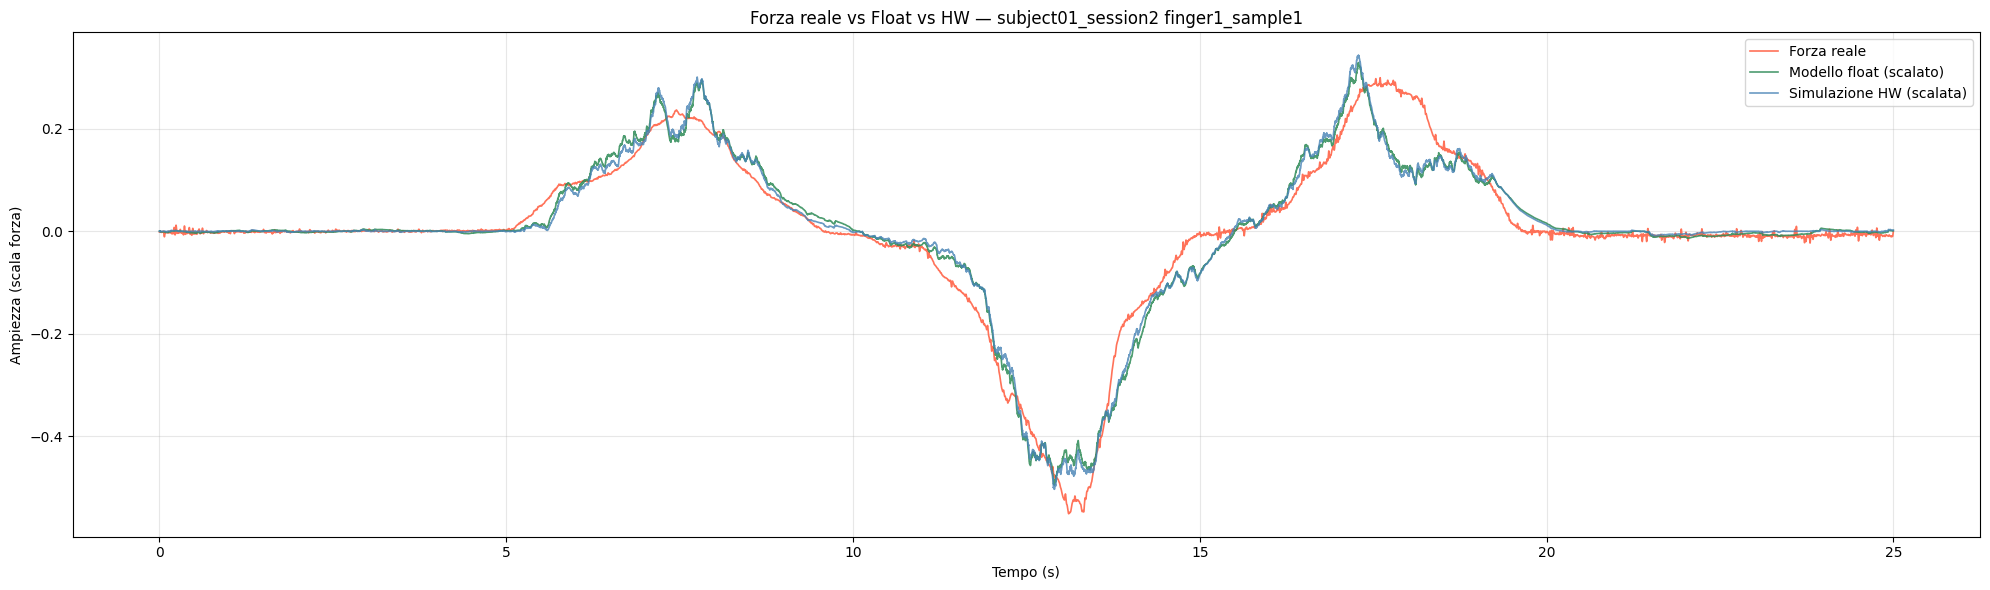

In [ ]:
dof    = 0
V_out     = np.array(V_out_hist)
scale_out = quant["fc_out"]["scale"]

v_hw   = V_out[:, dof] * scale_out
v_mod  = pred_float.astype(np.float64)
f_true = force_raw.astype(np.float64)

min_len = min(len(f_true), len(v_mod), len(v_hw))
f_true = f_true[:min_len]
v_mod  = v_mod[:min_len]
v_hw   = v_hw[:min_len]
t_axis = np.arange(min_len) / fs_target

# fattore LS: a = (x·y) / (x·x)
def best_scale(x, y):
    num = np.dot(x, y)
    den = np.dot(x, x) + 1e-8
    return num / den

a_mod = best_scale(v_mod, f_true)
a_hw  = best_scale(v_hw,  f_true)

v_mod_s = v_mod * a_mod
v_hw_s  = v_hw * a_hw

print(f"scale_mod={a_mod:.4g}, scale_hw={a_hw:.4g}")

fig, ax = plt.subplots(figsize=(20, 6))
ax.plot(t_axis, f_true,  color='tomato',    linewidth=1.2, label='Forza reale',    alpha=0.9)
ax.plot(t_axis, v_mod_s, color='seagreen',  linewidth=1.2, label='Modello float (scalato)',  alpha=0.85)
ax.plot(t_axis, v_hw_s,  color='steelblue', linewidth=1.2, label='Simulazione HW (scalata)', alpha=0.8)

ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Ampiezza (scala forza)')
ax.set_title(f'Forza reale vs Float vs HW — {SUBJECT}_{SESSION} finger1_{SAMPLE}')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
def pearson_corr(y, yhat, eps=1e-8):
    y = y.float(); yhat = yhat.float()
    ym = y.mean(); yhm = yhat.mean()
    num = ((y-ym)*(yhat-yhm)).sum()
    den = torch.sqrt(((y-ym)**2).sum() * ((yhat-yhm)**2).sum() + eps)
    return num / den

import torch

dof    = 0
V_out     = np.array(V_out_hist)
scale_out = quant["fc_out"]["scale"]

v_hw   = V_out[:, dof] / scale_out
v_mod  = pred_float
f_true = force_raw

min_len = min(len(f_true), len(v_mod), len(v_hw))
f_true_t = torch.from_numpy(f_true[:min_len]).float()
v_mod_t  = torch.from_numpy(v_mod[:min_len]).float()
v_hw_t   = torch.from_numpy(v_hw[:min_len]).float()

corr_f_mod  = pearson_corr(f_true_t, v_mod_t)
corr_f_hw   = pearson_corr(f_true_t, v_hw_t)
corr_mod_hw = pearson_corr(v_mod_t,  v_hw_t)

print(f"corr(Forza, Modello float) = {corr_f_mod.item():.4f}")
print(f"corr(Forza, Simulazione HW) = {corr_f_hw.item():.4f}")
print(f"corr(Modello float, HW)    = {corr_mod_hw.item():.4f}")


corr(Forza, Modello float) = 0.9687
corr(Forza, Simulazione HW) = 0.9691
corr(Modello float, HW)    = 0.9986


In [ ]:
def analyze_range(arr, name=""):
    """Stampa min, max, max|val| e bit necessari (2's complement)."""
    arr = np.asarray(arr)
    min_val = int(np.min(arr))
    max_val = int(np.max(arr))
    max_abs = max(abs(min_val), abs(max_val))
    if max_abs == 0:
        bits = 1  # solo il segno
    else:
        bits = int(np.floor(np.log2(max_abs))) + 2  # +1 segno, +1 margine
    print(f"[{name}] min = {min_val}, max = {max_val}, max|val| = {max_abs}, bits necessari = {bits}")
    return min_val, max_val, max_abs, bits

# Analisi range correnti / stati
analyze_range(mem_c1_rec, "Conv1")
analyze_range(mem_c2_rec, "Conv2")
analyze_range(mem_c3_rec, "Conv3")
analyze_range(mem_out_rec, "FC/OUT")

[Conv1] min = -1091, max = 429, max|val| = 1091, bits necessari = 12
[Conv2] min = -14599, max = 1498, max|val| = 14599, bits necessari = 15
[Conv3] min = -10548, max = 528, max|val| = 10548, bits necessari = 15
[FC/OUT] min = -20024, max = 13654, max|val| = 20024, bits necessari = 16


(-20024, 13654, 20024, 16)

### Estrazione pesi e parametri acceleratore

In [ ]:
# Converti in HEX per FPGA writer
weights1 = [format(int(v) & 0xFF, "02X") for v in conv1_kernels.flatten()]
weights2 = [format(int(v) & 0xFF, "02X") for v in conv2_kernels.flatten()]
weights3 = [format(int(v) & 0xFF, "02X") for v in conv3_kernels.flatten()]
weights4 = [format(int(v) & 0xFF, "02X") for v in fc_weights.flatten()]

In [ ]:
print ("\nPesi Conv1 (HEX):", weights1[:16], "...")
print ("Pesi Conv2 (HEX):", weights2[:16], "...")
print ("Pesi FC1 (HEX):", weights3[:16], "...")
print ("Pesi OUT (HEX):", weights4[:16], "...")


Pesi Conv1 (HEX): ['1C', '32', 'EB', '25', 'E1', '09', 'BE', '22', '3D', 'B8', '3C', '10', '23', '03', '21', 'DA'] ...
Pesi Conv2 (HEX): ['07', 'DA', 'D6', 'E2', 'D2', 'D0', '06', 'DA', 'DA', '07', '05', 'EB', '03', 'DC', '17', 'F2'] ...
Pesi FC1 (HEX): ['F5', 'FC', 'E3', 'E7', 'F6', 'EF', '11', '07', 'DD', 'F9', 'F6', 'FF', 'F4', 'FD', 'F1', 'D6'] ...
Pesi OUT (HEX): ['ED', 'F8', '0D', '14', '04', 'EA', '03', 'F8', 'F2', 'FA', '09', '15', 'E8', '08', '12', 'D8'] ...


In [ ]:
import os, numpy as np, io, math

# =========================================================
# PARAMETRI FPGA
# =========================================================
ZERO_WORD  = "0000" # padding word
GROUP_SIZE = 16 # numero di spike per riga di spike memory
PAD_TO     = 16 # se i pesi sono meno di 16 fai padding
WORDS_PER_SPLIT = 256 # words per bram
BASE_ADDR = 0x010000 # non dovrebbe essere utilizzato
# =========================================================
# UTILITY
# =========================================================
def to_int8_hex(val):
    return f"{(int(val) & 0xFF):02X}"

def next_pow2(n):
    if n <= 0: return 1
    p = 1
    while p < n: p <<= 1
    return p

# indices useful to store weights of dense layers in brams
# spikes are stored in words of 16, mirrored, in order to simplify
# hardware spike memory handling. Consequently, also weights must be mirrored.
def perm_dense_word16_indices(word=16):
    idx = np.arange(16, dtype=np.int32).reshape(8, 2) # 0,1; 2,3; ...; 14,15
    idx = idx[::-1, ::-1] # mirror left/right top/bottom: # 15,14; 13,12; ... ; 1,0
    return idx.reshape(-1)

# iterate perm_dense_word16_indices to mirror weights in weight mem
def apply_dense_word16_stream_to_weights(W_2d):
    W_2d = np.asarray(W_2d)
    n_out, n_in = W_2d.shape
    assert W_2d.ndim == 2
    base = perm_dense_word16_indices(16)
    perm = np.concatenate([base + off for off in range(0, n_in, 16)]).astype(np.int32)
    return W_2d[:, perm]

# flatten delle output feature
def as_2d_dense(W):
    W = np.squeeze(np.asarray(W))
    if W.ndim != 2:
        W = W.reshape(W.shape[0], -1)
    return W

# =========================================================
# SCRITTURA LAYER
# =========================================================
def write_conv_layer(W, fa, fb, fc, fd, layer_idx, addr):
    first_addr = addr
    words_ab = words_cd = 0 # ab core 1, cd core 2
    Cout, Cin, Kh, Kw = W.shape # #of, #if, kernel height, kernel width
    for co in range(Cout):
        for ci in range(Cin):
            mat  = np.flip(W[co, ci], axis=0) # mirror kernel
            vals = mat.reshape(-1).tolist() # flatten
            while len(vals) % 4 != 0:
                vals.append(0)
            for i in range(0, len(vals), 4):
                v0, v1, v2, v3 = map(to_int8_hex, vals[i:i+4]) # convert weights in hexadecimal
                if co % 2 == 0: # se OF è pari mette nel core 1
                    fa.write(f"{v0}{v1}\n"); fb.write(f"{v2}{v3}\n"); words_ab += 1
                else: # altrimenti nel core 2
                    fc.write(f"{v0}{v1}\n"); fd.write(f"{v2}{v3}\n"); words_cd += 1
    total = words_ab + words_cd
    print(f"[L{layer_idx} CONV ] addr=0x{first_addr:X}  parole_tot={total}  "
          f"(fa/fb={words_ab}  fc/fd={words_cd})")
    return total

def write_dense_layer(W, fa, fb, fc, fd, layer_idx, addr):
    first_addr = addr
    words_ab = words_cd = 0
    n_neu, n_syn = W.shape
    # # non utilizzato
    # non si sa perché funzioni, il senso è scrivere i pesi in uno spazio che sia
    # multiplo di 16 perché gli spike sono scritti in gruppi di 16
    wpr_raw = math.ceil(n_syn / GROUP_SIZE) * (PAD_TO // 4)
    print(f"[L{layer_idx} DENSE] words/neurone: {wpr_raw}  neu={n_neu} syn={n_syn}")

    # write weights file for dense layers.
    for j in range(n_neu):
        for blk_start in range(0, n_syn, GROUP_SIZE):
            blk = W[j, blk_start:blk_start + GROUP_SIZE].tolist()
            if len(blk) < PAD_TO:
                blk += [0] * (PAD_TO - len(blk))
            for i in range(0, len(blk), 4):
                v0, v1, v2, v3 = map(to_int8_hex, blk[i:i+4])
                if j % 2 == 0:
                    fa.write(f"{v0}{v1}\n"); fb.write(f"{v2}{v3}\n"); words_ab += 1
                else:
                    fc.write(f"{v0}{v1}\n"); fd.write(f"{v2}{v3}\n"); words_cd += 1
        # ← niente padding zero tra neuroni

    total = words_ab + words_cd
    print(f"[L{layer_idx} DENSE] addr=0x{first_addr:X}  parole_tot={total}  "
          f"(fa/fb={words_ab}  fc/fd={words_cd})")
    return total


# =========================================================
# COSTRUZIONE PESI
# =========================================================
W_conv1 = conv1_kernels.astype(np.int8)
W_conv2 = conv2_kernels.astype(np.int8)
W_conv3 = conv3_kernels.astype(np.int8)

# flatten dense layer
fc_2d = as_2d_dense(fc_weights)
n_out_fc, n_in_fc = fc_2d.shape
print(f"FC shape: {fc_2d.shape}  → blocchi da 16: {n_in_fc//16} interi + {n_in_fc%16} resto")

# numero input dense layer
num_full = n_in_fc // 16
rest     = n_in_fc % 16
hw_blocks = []
for b in range(num_full):
    blk = fc_2d[:, b*16:(b+1)*16]
    hw_blocks.append(apply_dense_word16_stream_to_weights(blk))
if rest > 0:
    last_blk = np.zeros((n_out_fc, 16), dtype=fc_2d.dtype)
    last_blk[:, :rest] = fc_2d[:, num_full*16:][:, ::-1]
    hw_blocks.append(last_blk)

W_fc_hw = np.concatenate(hw_blocks, axis=1)

print(f"\nShapes finali:")
print(f"  Conv1 = {W_conv1.shape}")
print(f"  Conv2 = {W_conv2.shape}")
print(f"  Conv3 = {W_conv3.shape}")
print(f"  FC_hw = {W_fc_hw.shape}")

# =========================================================
# NUMERO DI BRAM NECESSARIE PER SALVARE I PESI
# =========================================================
def estimate_dense_words_per_stream(W):
    n_neu, n_syn = W.shape
    # NON SI SA PERCHE FUNZIONI MA RESTITUISCE IL NUMERO DI RIGHE IN WEIGHT MEM DI UN NEURONE
    wpr = math.ceil(n_syn / GROUP_SIZE) * (PAD_TO // 4)  # ← no next_pow2
    n_even = math.ceil(n_neu / 2) # diviso 2 perché ogni core ha metà dei neuroni
    return n_even * wpr

def estimate_conv_words_per_stream(W):
    Cout, Cin, Kh, Kw = W.shape # h,w height and width of the kernel (3x3)
    vals = Kh * Kw
    while vals % 4 != 0: vals += 1
    total = Cout * Cin * (vals // 4)
    n_even = math.ceil(Cout / 2)    # OF pari su fa/fb → caso peggiore
    return n_even * Cin * (vals // 4)

est = (estimate_conv_words_per_stream(W_conv1) +
       estimate_conv_words_per_stream(W_conv2) +
       estimate_conv_words_per_stream(W_conv3) +
       estimate_dense_words_per_stream(W_fc_hw))

N_SPLITS = max(1, math.ceil(est / WORDS_PER_SPLIT))
print(f"Parole per stream (caso peggiore): {est}  →  N_SPLITS={N_SPLITS}")

# =========================================================
# DOVREBBE ESSERE SERVITO PER LO STREAM SPI DEI DATI
# PER OGNI LAYER SALVA INDIRIZZO E TIPO DI LAYER
# =========================================================
fa = io.StringIO(); fb = io.StringIO()
fc_buf = io.StringIO(); fd = io.StringIO()

addr = BASE_ADDR
# it will contain the base address of each layer in weight mem and layer ID and layer TYPE
addr_tracker = []

layers = [
    ("CONV",  W_conv1, write_conv_layer),
    ("CONV",  W_conv2, write_conv_layer),
    ("CONV",  W_conv3, write_conv_layer),
    ("DENSE", W_fc_hw, write_dense_layer),
]

for layer_idx, (ltype, W, write_fn) in enumerate(layers, 1):
    addr_tracker.append((layer_idx, ltype, addr))
    n_words = write_fn(W, fa, fb, fc_buf, fd, layer_idx, addr)
    addr += n_words // 2

# =========================================================
# CREAZIONE FILE DEI PESI
# =========================================================
def split_and_write(buf, base_name, n_splits, words_per_split):
    lines = buf.getvalue().splitlines()
    total = words_per_split * n_splits
    while len(lines) < total: # padding finale sull'ultima bram
        lines.append(ZERO_WORD)
    lines = lines[:total]
    for i in range(n_splits):
        chunk = lines[i*words_per_split:(i+1)*words_per_split]
        fname = f"{base_name}_{i+1}.hex"
        with open(fname, "w") as f:
            f.write("\n".join(chunk) + "\n")
        print(f"  [SPLIT] {fname}: {len(chunk)} parole")

# ── split ──
print("\n─── Scrittura file ───")
split_and_write(fa,     OUTPUT_DIR / "weights_1", N_SPLITS, WORDS_PER_SPLIT)
split_and_write(fb,     OUTPUT_DIR / "weights_2", N_SPLITS, WORDS_PER_SPLIT)
split_and_write(fc_buf, OUTPUT_DIR / "weights_3", N_SPLITS, WORDS_PER_SPLIT)
split_and_write(fd,     OUTPUT_DIR / "weights_4", N_SPLITS, WORDS_PER_SPLIT)

# ── address ──
with open(OUTPUT_DIR / "address.txt", "w") as f:
    f.write('1048576\n')

print("\n✅ DONE")


FC shape: (5, 400)  → blocchi da 16: 25 interi + 0 resto

Shapes finali:
  Conv1 = (16, 2, 3, 3)
  Conv2 = (8, 16, 3, 3)
  Conv3 = (16, 8, 3, 3)
  FC_hw = (5, 400)
Parole per stream (caso peggiore): 732  →  N_SPLITS=3
[L1 CONV ] addr=0x100000  parole_tot=96  (fa/fb=48  fc/fd=48)
[L2 CONV ] addr=0x100030  parole_tot=384  (fa/fb=192  fc/fd=192)
[L3 CONV ] addr=0x1000F0  parole_tot=384  (fa/fb=192  fc/fd=192)
[L4 DENSE] words/neurone: 100  neu=5 syn=400
[L4 DENSE] addr=0x1001B0  parole_tot=500  (fa/fb=300  fc/fd=200)

─── Scrittura file ───
  [SPLIT] emg\weights_1_1.hex: 256 parole
  [SPLIT] emg\weights_1_2.hex: 256 parole
  [SPLIT] emg\weights_1_3.hex: 256 parole
  [SPLIT] emg\weights_2_1.hex: 256 parole
  [SPLIT] emg\weights_2_2.hex: 256 parole
  [SPLIT] emg\weights_2_3.hex: 256 parole
  [SPLIT] emg\weights_3_1.hex: 256 parole
  [SPLIT] emg\weights_3_2.hex: 256 parole
  [SPLIT] emg\weights_3_3.hex: 256 parole
  [SPLIT] emg\weights_4_1.hex: 256 parole
  [SPLIT] emg\weights_4_2.hex: 256 p

### DEBUG : file dei pesi per ogni layer in esadecimale

un file in formato più leggibile rispetto ai weights_x.txt da caricare in bram con readmemh

In [ ]:
def to_hex_signed(val):
    return f"0x{int(val) & 0xFF:02X}"

def ensure_4d(arr):
    arr = np.array(arr)
    while arr.ndim < 4:
        arr = arr.reshape(arr.shape + (1,))
    return arr

def ensure_2d(arr):
    arr = np.squeeze(np.array(arr))
    if arr.ndim != 2:
        arr = arr.reshape(arr.shape[0], -1)
    return arr

# ── prep pesi ────────────────────────────────────────────────
W_conv1_q = ensure_4d(conv1_kernels.astype(np.int32))
W_conv2_q = ensure_4d(conv2_kernels.astype(np.int32))
W_conv3_q = ensure_4d(conv3_kernels.astype(np.int32))
W_fc_q    = ensure_2d(fc_weights.astype(np.int32))

print("=== Final shapes for readable dump ===")
print(f"  Conv1 = {W_conv1_q.shape}")
print(f"  Conv2 = {W_conv2_q.shape}")
print(f"  Conv3 = {W_conv3_q.shape}")
print(f"  FC    = {W_fc_q.shape}")
print("=======================================")

assert W_conv1_q.ndim == 4
assert W_conv2_q.ndim == 4
assert W_conv3_q.ndim == 4
assert W_fc_q.ndim    == 2

# ── funzione generica scrittura conv ────────────────────────
def write_conv_readable(path, name, W):
    Cout, Cin, Kh, Kw = W.shape
    with open(path, "w") as f:
        f.write(f"[{name}] shape={W.shape}\n\n")
        for co in range(Cout):
            for ci in range(Cin):
                f.write(f"OutCh {co}, InCh {ci}:\n")
                for kh in range(Kh):
                    vals = [to_hex_signed(v) for v in W[co, ci, kh]]
                    f.write(", ".join(vals) + "\n")
                f.write("\n")

def write_dense_readable(path, name, W):
    n_out, n_in = W.shape
    with open(path, "w") as f:
        f.write(f"[{name}] shape={W.shape}\n\n")
        for i in range(n_out):
            vals = [to_hex_signed(v) for v in W[i]]
            f.write(", ".join(vals) + "\n")

# ── scrittura ────────────────────────────────────────────────
write_conv_readable (OUTPUT_DIR / "weights_layer_1.txt", "Conv1", W_conv1_q)
write_conv_readable (OUTPUT_DIR / "weights_layer_2.txt", "Conv2", W_conv2_q)
write_conv_readable (OUTPUT_DIR / "weights_layer_3.txt", "Conv3", W_conv3_q)
write_dense_readable(OUTPUT_DIR / "weights_layer_4.txt", "FC",    W_fc_q)

print("✅ Creati weights_layer_1..4.txt in emg/")

=== Final shapes for readable dump ===
  Conv1 = (16, 2, 3, 3)
  Conv2 = (8, 16, 3, 3)
  Conv3 = (16, 8, 3, 3)
  FC    = (5, 400)
✅ Creati weights_layer_1..4.txt in emg/


### File di configurazione

In [ ]:
# mai testato, to be checked

input_files = [OUTPUT_DIR / "input_vec.txt"]
with open(OUTPUT_DIR / "flash.txt", "w") as outfile:
    for fn in input_files:
        if os.path.exists(fn):
            outfile.write(open(fn, "r").read())
        else:
            outfile.write(f"File {fn} not found.\n")
print("[DONE] flash.txt creato (pesi + input_vec concatenati).")

[DONE] flash.txt creato (pesi + input_vec concatenati).


In [ ]:
#@title INPUT VECTOR FILE WRITTEN AS CHAR ARRAYS USED TO WRITE BINARY FILES FOR FLASH PROGRAMMING

from pathlib import Path

OUTPUT_DIR = Path("emg")
OUTPUT_DIR.mkdir(exist_ok=True)

input_path = OUTPUT_DIR / "input_vec.txt"
output_path = OUTPUT_DIR / "samples.txt"

# Leggi i valori hex dal file (uno per riga o separati da spazi/virgole)
with open(input_path, "r") as f:
    raw = f.read()

# Parsing flessibile: supporta valori come "0x1A", "1A", interi decimali
tokens = raw.replace(",", " ").replace("\n", " ").split()
values = []
for t in tokens:
    t = t.strip()
    if not t:
        continue
    if t.startswith("0x") or t.startswith("0X"):
        values.append(int(t, 16))
    else:
        try:
            values.append(int(t, 16))  # prova hex senza prefisso
        except ValueError:
            values.append(int(t))      # fallback decimale

# Scrivi il file .h con 16 valori per riga
hex_strs = [f"0x{v & 0xFF:02X}" for v in values]
lines = []
for i in range(0, len(hex_strs), 16):
    chunk = hex_strs[i:i+16]
    lines.append(", ".join(chunk) + ",")

body = "\n\t".join(lines)

header_content = f"unsigned char samples[] = {{\t{body}}};"

with open(output_path, "w") as f:
    f.write(header_content)

print(f"✅ Scritto {len(values)} valori in {output_path}")

KeyboardInterrupt: 

In [ ]:
#@title CREATE SNN_INFERENCE.TXT FILES WHO CONTAINS NEURON CURRENTS I(t)

print("[INFO] Scrittura snn_inference.txt ...")

with open(OUTPUT_DIR / "snn_inference.txt", "w") as f:
    for t in range(T):

        # ═══════════════════════════════════════════════
        # CONV1 — 16 OF, 2 IF → per ogni coppia OF, per ogni IF
        # integrated_trace_conv1[0][t][of][ic] → (H1,W1)
        # ═══════════════════════════════════════════════
        n_out = len(integrated_trace_conv1[0][t])   # 16
        for of in range(0, n_out, 2):
            n_if = len(integrated_trace_conv1[0][t][of])  # 2
            for ic in range(n_if):
                integ0 = np.array(integrated_trace_conv1[0][t][of][ic])
                integ1 = np.array(integrated_trace_conv1[0][t][of+1][ic]) if of+1 < n_out else np.zeros_like(integ0)
                H1, W1 = integ0.shape
                for i in range(H1):
                    for j in range(W1):
                        f.write(f"{int(integ0[i,j])}\n{int(integ1[i,j])}\n")

        # ═══════════════════════════════════════════════
        # CONV2 — 8 OF, 16 IF
        # integrated_trace_conv2[0][t][of][ic] → (H2,W2)
        # ═══════════════════════════════════════════════
        n_out = len(integrated_trace_conv2[0][t])   # 8
        for of in range(0, n_out, 2):
            n_if = len(integrated_trace_conv2[0][t][of])  # 16
            for ic in range(n_if):
                integ0 = np.array(integrated_trace_conv2[0][t][of][ic])
                integ1 = np.array(integrated_trace_conv2[0][t][of+1][ic]) if of+1 < n_out else np.zeros_like(integ0)
                H2, W2 = integ0.shape
                for i in range(H2):
                    for j in range(W2):
                        f.write(f"{int(integ0[i,j])}\n{int(integ1[i,j])}\n")

        # ═══════════════════════════════════════════════
        # CONV3 — 16 OF, 8 IF
        # integrated_trace_conv3[0][t][of][ic] → (H3,W3)
        # ═══════════════════════════════════════════════
        n_out = len(integrated_trace_conv3[0][t])   # 16
        for of in range(0, n_out, 2):
            n_if = len(integrated_trace_conv3[0][t][of])  # 8
            for ic in range(n_if):
                integ0 = np.array(integrated_trace_conv3[0][t][of][ic])
                integ1 = np.array(integrated_trace_conv3[0][t][of+1][ic]) if of+1 < n_out else np.zeros_like(integ0)
                H3w, W3w = integ0.shape
                for i in range(H3w):
                    for j in range(W3w):
                        f.write(f"{int(integ0[i,j])}\n{int(integ1[i,j])}\n")

        # ═══════════════════════════════════════════════
        # FC OUT — 5 neuroni → coppie
        # V_out_hist[t] shape: (5,)
        # ═══════════════════════════════════════════════
        Vout = V_out_hist[t].ravel()
        for i in range(0, len(Vout), 2):
            v0 = int(Vout[i])
            v1 = int(Vout[i+1]) if i+1 < len(Vout) else 0
            f.write(f"{v0}\n{v1}\n")

print(f"[OK] snn_inference.txt scritto — {T} timestep")

[INFO] Scrittura snn_inference.txt ...


KeyboardInterrupt: 

In [ ]:
#@title CREATE CONFIG.TXT FILE FOR VERILOG MODULES CONFIGURATIONS

DW           = 8
BUFFER_WIDTH = 4

# dalla tua pipeline
INPUT_SPIKE   = X_hw.shape[2] * X_hw.shape[3] * 2  # 16×16×2 = 512 (pos+neg)
CHANNELS      = X_hw.shape[2] * X_hw.shape[3]       # 16×16 = 256
TIME_STEPS    = X_hw.shape[0]                        # 25000
N_OUTPUTS     = fc_weights.shape[0]                  # 5

print(f"[INPUT] CHANNELS={CHANNELS}  INPUT_SPIKE={INPUT_SPIKE}  T={TIME_STEPS}  N_OUT={N_OUTPUTS}")

with open(OUTPUT_DIR / "config.txt", "w") as f:
    f.write(f"`define DW           {DW}\n")
    f.write(f"`define INPUT_CHANNELS {CHANNELS}\n")
    f.write(f"`define INPUT_SPIKE_1  {INPUT_SPIKE}\n")
    f.write(f"`define N_OUTPUTS      {N_OUTPUTS}\n")
    f.write(f"`define TIME_STEPS     {TIME_STEPS}\n")
    f.write(f"`define BUFFER_WIDTH   {BUFFER_WIDTH}\n")

print("[OK] config.txt scritto in emg/")


[INPUT] CHANNELS=256  INPUT_SPIKE=512  T=100  N_OUT=5
[OK] config.txt scritto in emg/


In [ ]:
#@title FIRMWARE CONFIGURATION

with open(OUTPUT_DIR /'constants.h', 'wt') as f:
  f.write(f'#define WEIGHT_DEPTH 768\n')
  f.write(f'#define CHANNELS {CHANNELS}\n')
  f.write(f'#define TIME 9\n')

  f.write(f'#define SAMPLE_ADDR   1048576\n')

In [ ]:
#@title CREATE INSTRUCTIONS

# check if the convolutional layers use padding
def get_paddings_from_net(net):
    paddings = []
    for module in net.modules():
        if isinstance(module, torch.nn.Conv2d):
            p = module.padding
            paddings.append(p[0] if isinstance(p, tuple) else p)
    return paddings

paddings_from_net = get_paddings_from_net(model)
print(f"Padding rilevati dalla rete: {paddings_from_net}")

# ─────────────────────────────────────────────────────────────

class InstructionBuilder:
    def __init__(self, voltage_decay, threshold):
        self.voltage_decay = voltage_decay
        self.threshold     = threshold

    def build_instruction(
        self, layer_type, neuron=0, synapses=0, next_dim_input_feature=16,
        number_input_feature=0, number_output_feature=0,
        kernel_size=0, stride=0, size_input_feature=0,
        padding=0, square_dim_output_feature=0, size_output_feature=0,
        dense_next=False, base_address=0
    ):
        # maybe is not used, but,
        # it is the bits of the weight address used to point synapses
        if synapses > 4:
            bit_for_spike = math.ceil(math.log2(synapses / 4))
        else:
            bit_for_spike = 0

        # layer type: 0 = dense, 1 = conv, 2 = pooling, 3 = conv seguito da dense --> conv +  flatten
        # SYNAPSES è utilizzato per sapere quando è conclusa l'inferenza del layer, in hw genera spike_written
        if layer_type == 3:
            # conv + flatten
            SYNAPSES = (size_output_feature * size_output_feature * number_output_feature)//2
            print(f"  [LAYER_TYPE 3] OF={number_output_feature}  SF={size_output_feature}  SYN={SYNAPSES}")
        elif layer_type in (1, 2):
            # conv or pooling
            SYNAPSES = 255 # here it is not used
        elif layer_type == 0:
            # dense
            SYNAPSES = neuron // 2
        else:
            SYNAPSES = 0


        # instruction encoding
        instr  = 0
        instr |= ((layer_type & 0b11)                  << 78)
        instr |= ((int(self.voltage_decay) & 0xFFF)     << 52)
        instr |= ((self.threshold & 0x1FFF)             << 36)
        instr |= (((next_dim_input_feature - 1) & 0xF)  << 32) # to save 1 bit is decremented by 1
        instr |= ((SYNAPSES & 0x1FF)                    << 18)
        #instr |= ((1 if dense_next else 0)              << 79)

        # the base address is segmented into three sections
        ba = base_address // 2 & 0x1FF
        instr |= (((ba >> 6) & 0x7) << 49)
        instr |= (((ba >> 4) & 0x3) << 16)
        instr |= ((ba & 0xF)        <<  0)

        # for conv, pool, and conv + flatten
        if layer_type in (1, 2, 3):
            instr |= ((kernel_size & 0x3)                      << 76)
            instr |= ((stride & 0x3)                           << 69)
            instr |= (((number_input_feature  - 1) & 0x3F)     << 71) # to save 1 bit is decremented by 1
            instr |= (((number_output_feature - 1) & 0x3F)     << 64) # to save 1 bit is decremented by 1
            instr |= ((padding & 0x1)                          << 31)
            instr |= (((size_input_feature  - 1) & 0xF)        << 27) # to save 1 bit is decremented by 1
            instr |= (((size_output_feature - 1) & 0xF)        <<  4) # to save 1 bit is decremented by 1
            instr |= (((square_dim_output_feature - 1) & 0xFF) <<  8) # to save 1 bit is decremented by 1
        # dense
        else:
            instr |= (((neuron // 2 ) & 0x7F) << 71)
            instr |= ((bit_for_spike & 0x7)       << 64)

        return instr

    # convert the instruction of 80 bits in groups of 16 for bram
    def format_hex_80bit(self, instr):
        hex_str = f"{instr:020X}"
        return [hex_str[i:i+4] for i in range(0, 20, 4)]


# ─────────────────────────────────────────────────────────────
# compute convolutional layer output size
def infer_conv_output_size(h_in, k, stride, padding):
    return (h_in + 2*padding - k) // stride + 1

# for debug. It prints layers characteristics, such as layer type, IF/OF size and number, kernel, padding, ....
def infer_layer_descriptors(conv_kernels_list, fc_w,
                             decay_list, thresh_list,
                             input_h, input_w,
                             has_maxpool_after=None,
                             paddings=None):
    if has_maxpool_after is None:
        has_maxpool_after = set()
    if paddings is None:
        paddings = [None] * len(conv_kernels_list)

    descriptors = []
    h, w = input_h, input_w

    for i, W in enumerate(conv_kernels_list):
        Cout, Cin, Kh, Kw = W.shape
        K = Kh

        # padding: da rete se disponibile, altrimenti auto
        if paddings[i] is not None:
            padding = int(paddings[i])
        else:
            h_same  = infer_conv_output_size(h, K, 1, 1)
            padding = 1 if (h_same == h) else 0

        h_out = infer_conv_output_size(h, K, 1, padding)
        w_out = infer_conv_output_size(w, K, 1, padding)

        is_last_conv = (i == len(conv_kernels_list) - 1)
        dense_next   = is_last_conv and (i not in has_maxpool_after)

        descriptors.append({
            "type"       : "conv",
            "layer_type" : 3 if dense_next else 1,
            "Cin"  : Cin,  "Cout"  : Cout,
            "K"    : K,    "stride": 1,
            "h_in" : h,    "w_in"  : w,
            "h_out": h_out,"w_out" : w_out,
            "padding"    : padding,
            "dense_next" : dense_next,
            "decay"      : decay_list[i],
            "thresh"     : thresh_list[i],
        })
        print(f"  Conv{i+1}: ({Cin}→{Cout}) {h}×{w} → {h_out}×{w_out}  "
              f"K={K} pad={padding} dense_next={dense_next}")

        h, w = h_out, w_out

        if i in has_maxpool_after:
            h_mp, w_mp = h // 2, w // 2
            descriptors.append({
                "type"       : "maxpool",
                "layer_type" : 2,
                "Cout"       : Cout,
                "h_in"       : h,    "w_in" : w,
                "h_out"      : h_mp, "w_out": w_mp,
                "dense_next" : is_last_conv,
                "decay"      : decay_list[i],
                "thresh"     : thresh_list[i],
            })
            print(f"    MaxPool2×2: {h}×{w} → {h_mp}×{w_mp}  (layer_type=2)")
            h, w = h_mp, w_mp

    n_out_fc, n_in_fc = fc_w.shape[0], fc_w.shape[1]
    descriptors.append({
        "type" : "dense",
        "n_out": n_out_fc, "n_in": n_in_fc,
        "decay": decay_list[-1], "thresh": thresh_list[-1],
    })
    print(f"  FC   : {n_in_fc} → {n_out_fc}")
    return descriptors


# ─────────────────────────────────────────────────────────────
def generate_instructions_auto():
    print("[INFO] Inferenza topologia...")
    # print networks informations
    descs = infer_layer_descriptors(
        conv_kernels_list = [conv1_kernels, conv2_kernels, conv3_kernels],
        fc_w              = fc_weights,
        decay_list        = [DI_C1, DI_C2, DI_C3, DI_OUT],
        thresh_list       = [THRESH_C1, THRESH_C2, THRESH_C3, THRESH_OUT],
        input_h           = X_hw.shape[2],
        input_w           = X_hw.shape[3],
        has_maxpool_after = {1},
        paddings          = paddings_from_net,   # ← automatico dalla rete
    )

    base_addrs = [a & 0x1FF for _, _, a in addr_tracker]
    addr_iter  = iter(base_addrs)
    instrs, builders = [], []

    for desc in descs:
        ltype = desc["type"]

        if ltype == "conv":
            base_addr = next(addr_iter)
            b = InstructionBuilder(desc["decay"], desc["thresh"])
            instr = b.build_instruction(
                layer_type                = desc["layer_type"],
                number_input_feature      = desc["Cin"],
                number_output_feature     = desc["Cout"],
                kernel_size               = desc["K"],
                stride                    = desc["stride"],
                size_input_feature        = desc["h_in"],
                size_output_feature       = desc["h_out"],
                square_dim_output_feature = desc["h_out"] * desc["w_out"],
                next_dim_input_feature    = 16 if desc["dense_next"] else desc["h_out"],  # ← modifica
                padding                   = desc["padding"],
                dense_next                = desc["dense_next"],
                base_address              = base_addr,
            )

        elif ltype == "maxpool":
            b = InstructionBuilder(desc["decay"], desc["thresh"])
            instr = b.build_instruction(
                layer_type                = 2,
                number_input_feature      = desc["Cout"],   # stessi canali in/out
                number_output_feature     = desc["Cout"],
                kernel_size               = 2,              # pool 2×2
                stride                    = 2,
                size_input_feature        = desc["h_in"],
                size_output_feature       = desc["h_out"],
                square_dim_output_feature = desc["h_out"] * desc["w_out"],
                next_dim_input_feature    = desc["h_out"],
                padding                   = 0,
                dense_next                = desc["dense_next"],
                base_address              = 0,
            )

        else:  # dense
            base_addr = next(addr_iter)
            b = InstructionBuilder(desc["decay"], desc["thresh"])
            instr = b.build_instruction(
                layer_type             = 0,
                neuron                 = desc["n_out"],
                synapses               = desc["n_in"],
                next_dim_input_feature = 16,
                dense_next             = False,
                base_address           = base_addr,
            )

        instrs.append(instr)
        builders.append(b)

    with open(OUTPUT_DIR / "instruction.hex", "w") as f:
        for instr, b in zip(instrs, builders):
            for line in b.format_hex_80bit(instr):
                f.write(line + "\n")

    print(f"\n✅ instruction.hex — {len(instrs)} istruzioni in emg/")
    for i, (desc, instr) in enumerate(zip(descs, instrs), 1):
        print(f"   L{i} [{desc['type']:7s}]: 0x{instr:020X}")


generate_instructions_auto()

Padding rilevati dalla rete: [0, 1, 0]
[INFO] Inferenza topologia...
  Conv1: (2→16) 16×16 → 14×14  K=3 pad=0 dense_next=False
  Conv2: (16→8) 14×14 → 14×14  K=3 pad=1 dense_next=False
    MaxPool2×2: 14×14 → 7×7  (layer_type=2)
  Conv3: (8→16) 7×7 → 5×5  K=3 pad=0 dense_next=True
  FC   : 400 → 5
  [LAYER_TYPE 3] OF=16  SF=5  SYN=200

✅ instruction.hex — 5 istruzioni in emg/
   L1 [conv   ]: 0x70AFE850060D7BFCC3D0
   L2 [conv   ]: 0x77A7FBD004CDEBFDC3D8
   L3 [maxpool]: 0xA3C7FBD004C66BFC3060
   L4 [conv   ]: 0xF3AFF362049F33231848
   L5 [dense  ]: 0x0107FF46000F00090008


In [ ]:
#@title ZIP ARCHIVE CREATION

zip_name = f"{application}.zip"
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for fp in OUTPUT_DIR.rglob("*"):
        if fp.is_file():
            arcname = fp.relative_to(OUTPUT_DIR.parent)
            zipf.write(fp, arcname)

print(f"✅ Creato archivio: {zip_name}")

✅ Creato archivio: emg.zip
